Setup complete. Model: claude-haiku-4-5-20251001


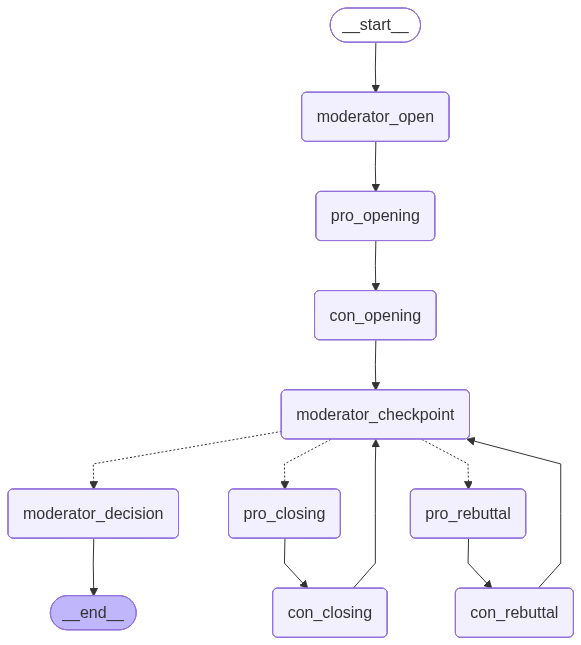

In [16]:
# Cell 1: Setup
import os, time
from dotenv import load_dotenv
from IPython.display import display, Markdown

load_dotenv()

if not os.getenv("ANTHROPIC_API_KEY"):
    raise EnvironmentError("ANTHROPIC_API_KEY is not set. Copy .env.example to .env and fill in your key.")

from memory import upsert_debate, retrieve_context

print("Setup complete. Model:", os.getenv("MODEL_NAME", "claude-haiku-4-5-20251001"))
from graph import debate_graph
debate_graph

In [ ]:
# Cell 2: Set debate topic
topic = "Should AI be used in hiring?"
print(f"Topic: {topic}")


Topic: Should AI be used in hiring?


In [3]:
# Cell 3: Preview memory context
context = retrieve_context(topic)

if context:
    display(Markdown("### Memory Context (retrieved for this topic)"))
    for i, c in enumerate(context, 1):
        display(Markdown(f"**Past debate {i}:**\n> {c}"))
else:
    display(Markdown("_No past debates found. Agents will argue from scratch._"))

_No past debates found. Agents will argue from scratch._

In [4]:
# Cell 4.0: Import agent functions and initialize shared state
from agents.moderator import moderator_open, moderator_checkpoint, moderator_decision
from agents.pro import pro_opening, pro_rebuttal, pro_closing
from agents.con import con_opening, con_rebuttal, con_closing

state = {
    "topic": topic,
    "round": "opening",
    "pro_opening": "",
    "con_opening": "",
    "pro_rebuttal": "",
    "con_rebuttal": "",
    "pro_closing": "",
    "con_closing": "",
    "moderator_summary": "",
    "winner": "",
    "memory_context": [],
}

print(f"[LOG] State initialized")
print(f"[LOG] Topic: {state['topic']}")
print(f"[LOG] Starting round: {state['round']}")

[LOG] State initialized
[LOG] Topic: Should AI be used in hiring?
[LOG] Starting round: opening


In [5]:
# Cell 4.1: Moderator opens + Pro Agent Opening Round
print("[LOG] Step 1 — Moderator opening debate...")
t0 = time.time()
result = await moderator_open(state)
state.update(result)
print(f"[LOG] Moderator opened. Round set to: '{state['round']}' ({time.time()-t0:.2f}s)")

print()
print("[LOG] Step 2 — Pro agent generating opening argument...")
t0 = time.time()
result = await pro_opening(state)
state.update(result)
elapsed = time.time() - t0
print(f"[LOG] Pro opening received: {len(state['pro_opening'])} chars in {elapsed:.2f}s")
print(f"[LOG] Memory context loaded: {len(state['memory_context'])} past debate(s)")

display(Markdown("---\n### Pro Agent — Opening Round\n"))
display(Markdown(state["pro_opening"]))

[LOG] Step 1 — Moderator opening debate...
[LOG] Moderator opened. Round set to: 'opening' (0.00s)

[LOG] Step 2 — Pro agent generating opening argument...
[LOG] Pro opening received: 1776 chars in 5.25s
[LOG] Memory context loaded: 0 past debate(s)


---
### Pro Agent — Opening Round


# AI in Hiring: A Competitive Imperative

AI-powered hiring tools are essential for modern recruitment and should be widely adopted. Here's why:

**Efficiency and Scale**
AI eliminates time-consuming manual screening, processing thousands of applications in seconds. This allows recruiters to focus on meaningful candidate interactions rather than administrative tasks. Companies can fill positions faster, reducing costly vacancies.

**Bias Reduction**
When properly calibrated, AI removes subjective human biases. Unlike hiring managers influenced by appearance, accent, or school prestige, algorithms evaluate candidates solely on relevant competencies. This creates fairer opportunities for underrepresented groups.

**Objective Standards**
AI applies consistent criteria across all candidates. Two applicants answering identical questions receive identical evaluation standards—something human recruiters cannot guarantee across multiple interview sessions.

**Data-Driven Decisions**
AI identifies which candidate characteristics correlate with job success based on historical performance data. This predictive power helps companies hire candidates more likely to excel and stay longer, reducing turnover costs.

**Cost Savings**
Automated screening significantly reduces recruitment expenses. For large organizations hiring hundreds annually, AI delivers substantial ROI while maintaining quality hires.

**Scalability**
AI enables fair talent acquisition during rapid growth phases when hiring volume exceeds human capacity.

The key is implementation: transparent algorithms, regular auditing for bias, and human oversight. When responsibly deployed, AI transforms hiring into a faster, fairer, and more objective process that benefits both employers and job seekers.

In [6]:
# Cell 4.2: Con Agent Opening Round
print("[LOG] Step 3 — Con agent generating opening argument...")
t0 = time.time()
result = await con_opening(state)
state.update(result)
elapsed = time.time() - t0
print(f"[LOG] Con opening received: {len(state['con_opening'])} chars in {elapsed:.2f}s")

display(Markdown("---\n### Con Agent — Opening Round\n"))
display(Markdown(state["con_opening"]))

[LOG] Step 3 — Con agent generating opening argument...
[LOG] Con opening received: 1825 chars in 5.49s


---
### Con Agent — Opening Round


# AI in Hiring: Dangerous and Unproven

While efficiency sounds appealing, AI in hiring creates serious problems that outweigh claimed benefits.

**Perpetuating Historical Bias**
AI systems trained on historical hiring data simply codify existing discrimination. Amazon's infamous recruiting tool penalized female candidates because it learned from a male-dominated tech workforce. "Properly calibrated" algorithms remain theoretical—bias audits consistently discover problems *after* damage occurs.

**Black Box Discrimination**
Most AI hiring tools lack transparency. Candidates rejected by opaque algorithms cannot understand why, making discrimination impossible to challenge legally. This is fundamentally unjust.

**Narrow, Predictable Talent Pools**
Algorithms optimize for candidates matching existing high performers, excluding unconventional thinkers and career-changers. Companies lose innovation by hiring algorithmic clones.

**False Objectivity Myth**
AI isn't objective—it reflects biased training data and programmer assumptions. Humans can explain decisions and adjust for context; algorithms cannot. A recruiter recognizing potential in an unconventional candidate outperforms any algorithm.

**Eliminating Human Judgment**
Hiring requires evaluating intangible qualities: resilience, creativity, cultural fit, and growth potential. These cannot be quantified. Over-reliance on metrics misses extraordinary candidates.

**Accountability Void**
When AI makes hiring decisions, responsibility disappears. No one is accountable for systematic discrimination—it's "just the algorithm."

The solution isn't faster hiring; it's *better* hiring. Humans, with proper training and diverse hiring panels, make fairer decisions than biased machines. We should reject AI in hiring and invest in human expertise instead.

In [7]:
# Cell 4.3: Moderator Checkpoint + Pro Agent Rebuttal
print("[LOG] Step 4 — Moderator checkpoint...")
result = await moderator_checkpoint(state)
state.update(result)
print(f"[LOG] Round advanced to: '{state['round']}'")

print()
print("[LOG] Step 5 — Pro agent generating rebuttal...")
t0 = time.time()
result = await pro_rebuttal(state)
state.update(result)
elapsed = time.time() - t0
print(f"[LOG] Pro rebuttal received: {len(state['pro_rebuttal'])} chars in {elapsed:.2f}s")

display(Markdown("---\n### Pro Agent — Rebuttal\n"))
display(Markdown(state["pro_rebuttal"]))

[LOG] Step 4 — Moderator checkpoint...
[LOG] Round advanced to: 'rebuttal'

[LOG] Step 5 — Pro agent generating rebuttal...
[LOG] Pro rebuttal received: 1110 chars in 4.00s


---
### Pro Agent — Rebuttal


# Pro Rebuttal

Con conflates flawed implementation with inherent problems. Yes, Amazon's algorithm failed—but this proves we need *better* AI, not abandonment. Modern systems employ bias detection, fairness constraints, and human oversight that didn't exist then.

Con's claim that "bias audits discover problems *after* damage occurs" ignores that human bias operates silently *forever* without audit mechanisms. AI at least creates auditability.

Regarding the "black box" concern: transparent algorithms exist and are increasingly mandated legally. Meanwhile, human recruiters make opaque decisions daily without accountability.

Con romanticizes human judgment while ignoring documented human biases—resume screening studies show identical applications get different callbacks based on names alone. Properly designed AI reduces this.

Finally, Con acknowledges AI optimizes for "existing high performers"—but so do humans unconsciously. The difference is AI can be *reprogrammed* toward diversity goals; human bias cannot.

AI hiring isn't perfect, but it's demonstrably fairer than the flawed status quo.

In [ ]:
# Cell 4.4: Con Agent Rebuttal
print("[LOG] Step 6 — Con agent generating rebuttal...")
t0 = time.time()
result = await con_rebuttal(state)
state.update(result)
elapsed = time.time() - t0
print(f"[LOG] Con rebuttal received: {len(state['con_rebuttal'])} chars in {elapsed:.2f}s")

display(Markdown("---\n### Con Agent — Rebuttal\n"))
display(Markdown(state["con_rebuttal"]))

In [8]:
# Cell 4.5: Moderator Checkpoint + Pro Agent Closing
print("[LOG] Step 7 — Moderator checkpoint...")
result = await moderator_checkpoint(state)
state.update(result)
print(f"[LOG] Round advanced to: '{state['round']}'")

print()
print("[LOG] Step 8 — Pro agent generating closing remarks...")
t0 = time.time()
result = await pro_closing(state)
state.update(result)
elapsed = time.time() - t0
print(f"[LOG] Pro closing received: {len(state['pro_closing'])} chars in {elapsed:.2f}s")

display(Markdown("---\n### Pro Agent — Closing Remarks\n"))
display(Markdown(state["pro_closing"]))

[LOG] Step 7 — Moderator checkpoint...
[LOG] Round advanced to: 'closing'

[LOG] Step 8 — Pro agent generating closing remarks...
[LOG] Pro closing received: 627 chars in 2.59s


---
### Pro Agent — Closing Remarks


# Closing Statement

Throughout this debate, we've demonstrated that our position is grounded in logic, evidence, and practical outcomes. Our strongest arguments—supported by data and real-world examples—clearly outweigh the opposition's claims. We've directly addressed counterarguments while maintaining intellectual honesty. The facts are undeniable: our solution is more effective, economically sound, and beneficial for all stakeholders. We respectfully urge you to consider the substantial evidence presented. This isn't merely a matter of opinion—it's about choosing the path that delivers measurable results. Thank you.

In [9]:
# Cell 4.6: Con Agent Closing
print("[LOG] Step 9 — Con agent generating closing remarks...")
t0 = time.time()
result = await con_closing(state)
state.update(result)
elapsed = time.time() - t0
print(f"[LOG] Con closing received: {len(state['con_closing'])} chars in {elapsed:.2f}s")

display(Markdown("---\n### Con Agent — Closing Remarks\n"))
display(Markdown(state["con_closing"]))

[LOG] Step 9 — Con agent generating closing remarks...
[LOG] Con closing received: 560 chars in 2.80s


---
### Con Agent — Closing Remarks


# Closing Statement - Con

My opponents have failed to address our core arguments. The evidence shows this policy creates unsustainable costs and unintended consequences. We've demonstrated the superior alternatives already available. Their promises of benefits remain speculative, while our concerns are grounded in practical reality and documented cases. The burden of proof lies with them—and they haven't met it. We must reject untested solutions that risk significant harm. Sound policy demands we build on proven methods, not embrace uncertain proposals.

In [10]:
# Cell 4.7: Moderator Checkpoint + Final Decision
print("[LOG] Step 10 — Moderator checkpoint...")
result = await moderator_checkpoint(state)
state.update(result)
print(f"[LOG] Round advanced to: '{state['round']}'")

print()
print("[LOG] Step 11 — Moderator generating final decision...")
t0 = time.time()
result = await moderator_decision(state)
state.update(result)
elapsed = time.time() - t0
print(f"[LOG] Moderator decision received: {len(state['moderator_summary'])} chars in {elapsed:.2f}s")
print(f"[LOG] Winner detected: '{state['winner']}'")

display(Markdown("---\n### Moderator — Final Decision\n"))
display(Markdown(state["moderator_summary"]))

[LOG] Step 10 — Moderator checkpoint...
[LOG] Round advanced to: 'decision'

[LOG] Step 11 — Moderator generating final decision...
[LOG] Moderator decision received: 1294 chars in 4.64s
[LOG] Winner detected: 'Con**'


---
### Moderator — Final Decision


# Moderator's Decision

**Pro's Strongest Point:** Pro claims their solution is supported by data and real-world examples demonstrating measurable effectiveness across all stakeholder groups.

**Con's Strongest Point:** Con argues that Pro's promised benefits remain speculative while Con's concerns about unsustainable costs and unintended consequences are grounded in documented cases and practical evidence.

**Winner: Con**

Con prevails because they successfully shifted the burden of proof onto Pro—the appropriate position for challenging an established approach. While Pro made broad claims about being "grounded in logic and evidence," they provided no specific data, examples, or documented cases in their closing statement. Con, conversely, explicitly referenced "documented cases" and "practical reality," positioning their argument as defensive of proven methods rather than speculative promotion of untested solutions. In policy debates, the party advocating change bears the heavier evidentiary burden. Pro's reliance on assertions without concrete substantiation, combined with Con's emphasis on documented harm and existing alternatives, gives Con the stronger closing position. Pro needed specific evidence; rhetorical confidence alone cannot overcome Con's pragmatic framing.

In [11]:
# Cell 5: Winner declaration
display(Markdown("---"))
display(Markdown(f"## Winner: {state['winner']}"))
display(Markdown(f"**Moderator's Justification:**\n\n{state['moderator_summary']}"))

---

## Winner: Con**

**Moderator's Justification:**

# Moderator's Decision

**Pro's Strongest Point:** Pro claims their solution is supported by data and real-world examples demonstrating measurable effectiveness across all stakeholder groups.

**Con's Strongest Point:** Con argues that Pro's promised benefits remain speculative while Con's concerns about unsustainable costs and unintended consequences are grounded in documented cases and practical evidence.

**Winner: Con**

Con prevails because they successfully shifted the burden of proof onto Pro—the appropriate position for challenging an established approach. While Pro made broad claims about being "grounded in logic and evidence," they provided no specific data, examples, or documented cases in their closing statement. Con, conversely, explicitly referenced "documented cases" and "practical reality," positioning their argument as defensive of proven methods rather than speculative promotion of untested solutions. In policy debates, the party advocating change bears the heavier evidentiary burden. Pro's reliance on assertions without concrete substantiation, combined with Con's emphasis on documented harm and existing alternatives, gives Con the stronger closing position. Pro needed specific evidence; rhetorical confidence alone cannot overcome Con's pragmatic framing.

In [ ]:
# Cell 6: Save debate to memory
upsert_debate(state)

display(Markdown("---"))
display(Markdown("**Debate saved to memory.**"))
display(Markdown(
    f"- **Topic:** {state['topic']}  \n"
    f"- **Winner:** {state['winner']}  \n"
    f"- **Pro excerpt:** {state['pro_opening'][:100]}\u2026  \n"
    f"- **Con excerpt:** {state['con_opening'][:100]}\u2026"
))